In [ ]:
import pandas as pd
import numpy as np
import librosa

# Load dataset
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

# Initialize lists for features and labels
features = []
labels = []
genders = [] 

# Read WAV files and extract features
for f in df.index:
    file_path = 'data/' + f
    try:
        signal, rate = librosa.load(file_path, sr=None)
        df.at[f, 'length'] = len(signal) / rate
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)

        if mfccs_mean.shape[0] == 13:
            features.append(mfccs_mean)
            labels.append(df.at[f, 'Emotion'])  
            genders.append(df.at[f, 'Gender'])  

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Convert features and labels to arrays
X = np.array(features)
y = np.array(labels)
genders = np.array(genders)

# Create a DataFrame
df_features = pd.DataFrame(X)
df_features['Emotion'] = y
df_features['Gender'] = genders

# Check original distribution
print("Original dataset distribution:")
print(df_features['Emotion'].value_counts())
print(df_features['Gender'].value_counts())

#  Oversampling to balance the dataset by Emotion and Gender
balanced_df = pd.DataFrame()

# Identify the maximum count for each emotion
max_counts = df_features['Emotion'].value_counts().max()

for (emotion, gender), group in df_features.groupby(['Emotion', 'Gender']):
    print(f"Group: {emotion}, {gender} - Size: {len(group)}")
    
    # Oversample the group if its size is less than the max count
    if len(group) < max_counts:
        group = group.sample(max_counts, replace=True)
    
    balanced_df = pd.concat([balanced_df, group], ignore_index=True)

# # Test
# gender_distribution = df_features.groupby(['Emotion', 'Gender']).size()
# max_count = gender_distribution.max()
# # Initialize balanced DataFrame
# balanced_df = pd.DataFrame()

# for (emotion, gender), count in gender_distribution.items():
#     label_df = df[(df['Emotion'] == emotion) & (df['Gender'] == gender)]
#     # Oversample if the current class has less than max_count
#     if len(label_df) < max_count:
#         label_df = label_df.sample(max_count, replace=True)
        
#     balanced_df = pd.concat([balanced_df, label_df], ignore_index=False)

# Check the balanced dataset
print("Balanced dataset distribution:")
print(balanced_df['Emotion'].value_counts())

In [1]:
import pandas as pd
import numpy as np
import librosa

# Load dataset
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

# Initialize lists for features and labels
features = []
labels = []
genders = [] 

# Read WAV files and extract features
for f in df.index:
    file_path = 'data/' + f
    try:
        signal, rate = librosa.load(file_path, sr=None)
        df.at[f, 'length'] = len(signal) / rate
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)

        if mfccs_mean.shape[0] == 13:
            features.append(mfccs_mean)
            labels.append(df.at[f, 'Emotion'])  
            genders.append(df.at[f, 'Gender'])  

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Convert features and labels to arrays
X = np.array(features)
y = np.array(labels)
genders = np.array(genders)

# Create a DataFrame
df_features = pd.DataFrame(X)
df_features['Emotion'] = y
df_features['Gender'] = genders

# Check original distribution
print("Original dataset distribution:")
print(df_features['Emotion'].value_counts())
print(df_features['Gender'].value_counts())

# Oversampling process
gender_distribution = df_features.groupby(['Emotion', 'Gender']).size()
max_count = gender_distribution.max()

# Initialize balanced DataFrame
balanced_df = pd.DataFrame()

for (emotion, gender), count in gender_distribution.items():
    label_df = df_features[(df_features['Emotion'] == emotion) & (df_features['Gender'] == gender)]
    # Oversample if the current class has less than max_count
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
        
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check the balanced dataset
print("Balanced dataset distribution:")
print(balanced_df['Emotion'].value_counts())
print(balanced_df['Gender'].value_counts())


Original dataset distribution:
Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64
Gender
M    720
F    720
Name: count, dtype: int64
Balanced dataset distribution:
Emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64
Gender
F    768
M    768
Name: count, dtype: int64


In [ ]:
print(balanced_df['Gender'].value_counts())

# Prepare the final feature and label arrays
X_balanced = balanced_df.iloc[:, :-2].values  # Exclude Emotion and Gender columns
y_balanced = balanced_df['Emotion'].values

In [3]:
df_features.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,Emotion,Gender
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,-7.861652,-2.124282,2.849204,neutral,M
1,-719.128296,70.201569,1.168397,13.122541,7.836950,14.411292,-4.111360,4.468973,-3.539367,-3.658607,-7.648504,-1.477077,3.031821,neutral,M
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,-7.499283,-2.962266,1.873485,neutral,M
3,-710.975281,67.564888,5.782241,13.230726,6.190846,12.628252,-1.675169,5.657494,-4.950634,-3.477545,-7.416558,-1.937004,2.271525,neutral,M
4,-759.921753,75.783524,6.023605,14.557394,6.454187,14.631508,-3.004551,4.620970,-5.200016,-0.707430,-7.790287,-3.564948,2.180970,calm,M


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Accuracy: 0.90
Classification Report:
              precision    recall  f1-score   support

       angry       0.89      0.92      0.91        88
        calm       0.90      0.93      0.91        80
     disgust       0.93      0.86      0.89        72
     fearful       0.81      0.89      0.85        76
       happy       0.88      0.93      0.90        68
     neutral       0.94      0.99      0.96        73
         sad       0.97      0.86      0.91        72
   surprised       0.90      0.81      0.85        86

    accuracy                           0.90       615
   macro avg       0.90      0.90      0.90       615
weighted avg       0.90      0.90      0.90       615



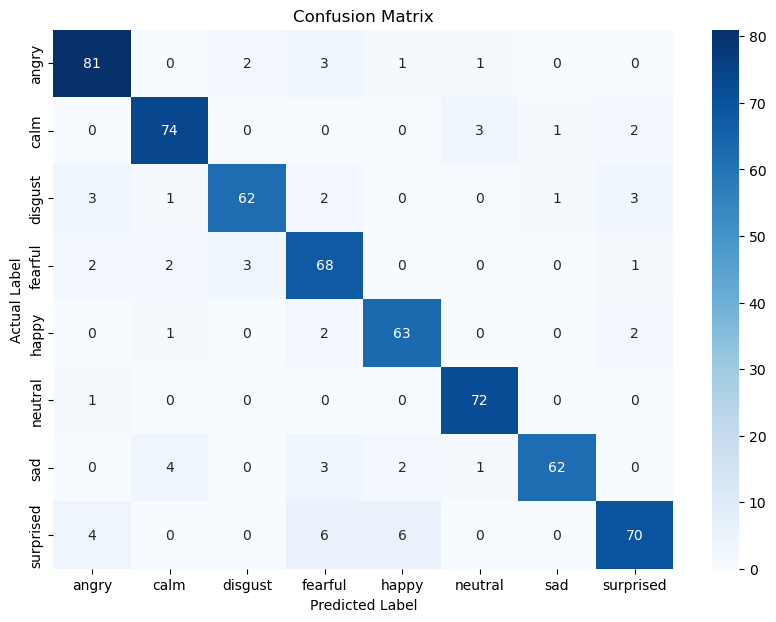

In [13]:
# Prepare the final feature and label arrays
X_balanced = balanced_df.iloc[:, :-2].values  # Features excluding Emotion and Gender columns
y_balanced = balanced_df['Emotion'].values  # Target variable

# Split the balanced data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Training the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# classification report for more metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_balanced), 
            yticklabels=np.unique(y_balanced))

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.47
Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.55      0.52        31
        calm       0.50      0.52      0.51        44
     disgust       0.50      0.42      0.46        33
     fearful       0.39      0.33      0.36        45
       happy       0.32      0.35      0.34        31
     neutral       0.72      0.85      0.78        52
         sad       0.33      0.30      0.31        37
   surprised       0.27      0.26      0.26        35

    accuracy                           0.47       308
   macro avg       0.44      0.45      0.44       308
weighted avg       0.46      0.47      0.46       308



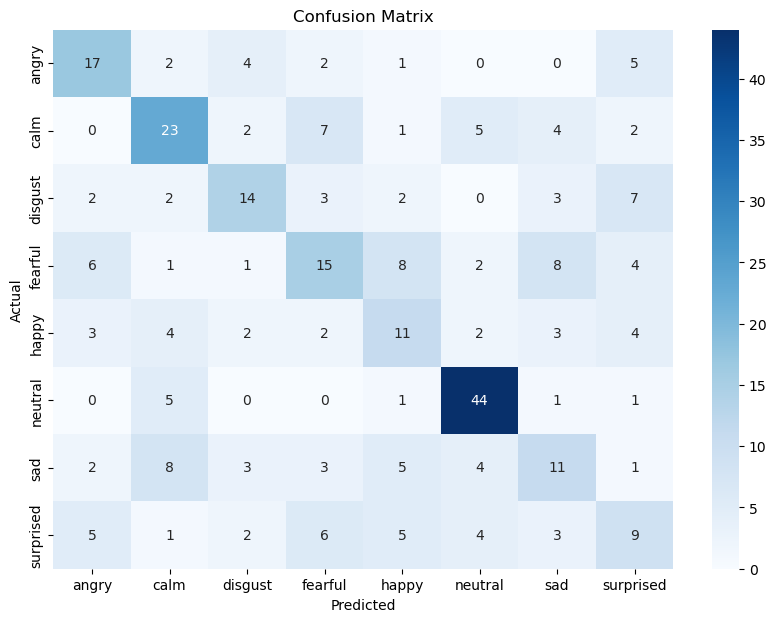

In [3]:
# Data Preprocessing, Feature Extraction
X = balanced_df.drop(columns=['Emotion', 'Gender']).values  # Assuming MFCCs are in the DataFrame
y = balanced_df['Emotion'].values

# Model Preparation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
clf = DecisionTreeClassifier(random_state=42)  # Initialize the Decision Tree classifier
clf.fit(X_train, y_train)  # Train the classifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()